In [14]:
#!pip install -U sktime matplotlib pandas seaborn statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 11.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviou

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sktime.utils.plotting import plot_series, plot_windows

from sktime.datasets import load_airline
from sktime.forecasting.model_selection import (
    temporal_train_test_split,
    ForecastingGridSearchCV,
    ExpandingWindowSplitter,
)

from sktime.performance_metrics.forecasting import MeanSquaredError
from sktime.forecasting.compose import make_reduction, ForecastingPipeline
from sktime.transformations.series.lag import Lag
from sktime.forecasting.base import ForecastingHorizon

from sklearn.linear_model import Ridge


# Make Database

In [79]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.waterqualitydata.us/data/Result/search"

def get_bbox_data(bbox, location_name):

    params = [
        ("bBox", bbox),
        ("dataProfile", "resultPhysChem"),
        ("providers", "NWIS"),
        ("providers", "STORET"),
        ("mimeType", "csv"),
        ("zip", "no"),
        ("startDateLo", "01-01-2019"),
        ("startDateHi", "12-31-2023"),
    ]

    r = requests.get(url, params=params, timeout=180)

    if r.status_code != 200:
        print(f"Failed request for {location_name}")
        return None

    df = pd.read_csv(StringIO(r.text))

    df["LocationName"] = location_name
    df["BBox"] = bbox

    return df



def make_database(locations, columns_to_keep=None):

    all_data = []

    for name, bbox in locations.items():

        df = get_bbox_data(bbox, name)

        if df is not None:
            all_data.append(df)

    if len(all_data) == 0:
        raise ValueError("No data downloaded")

    database = pd.concat(all_data, ignore_index=True)

    if columns_to_keep is not None:
        database = database[columns_to_keep]

    return database

In [80]:
columns_to_keep = [
    "LocationName",
    "BBox",
    "ActivityStartDate",
    "ActivityStartTime/Time",
    "MonitoringLocationIdentifier",
    "ActivityDepthHeightMeasure/MeasureValue",
    "ActivityMediaName",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode",
    "ResultStatusIdentifier",
    "MeasureQualifierCode",
    "DetectionQuantitationLimitMeasure/MeasureValue",
    "ResultDetectionConditionText",
    "ProjectIdentifier",
    "ResultAnalyticalMethod/MethodName",
    "ProviderName",
    "ActivityDepthHeightMeasure/MeasureUnitCode",
]

locations = {
    "salt lake city": "-112.10,40.65,-111.75,40.85",
}

In [81]:
database = make_database(locations, columns_to_keep)
database.shape

(96525, 18)

In [13]:
database.iloc[98000:98005]

,LocationName,BBox,ActivityStartDate,ActivityStartTime/Time,MonitoringLocationIdentifier,ActivityDepthHeightMeasure/MeasureValue,ActivityMediaName,CharacteristicName,ResultMeasureValue,ResultMeasure/MeasureUnitCode,ResultStatusIdentifier,MeasureQualifierCode,DetectionQuantitationLimitMeasure/MeasureValue,ResultDetectionConditionText,ProjectIdentifier,ResultAnalyticalMethod/MethodName,ProviderName,ActivityDepthHeightMeasure/MeasureUnitCode
98000,montgomery,"-86.45,32.30,-86.15,32.45",2019-10-16,10:38:00,21AWIC-81,NaN,Water,Kjeldahl nitrogen,.228,mg/L,Final,NaN,NaN,NaN,876,351.2 ~ EPA; Total Kjeldahl Nitrogen by Colori...,STORET,NaN
98001,montgomery,"-86.45,32.30,-86.15,32.45",2019-07-17,14:22:00,21AWIC-164,NaN,Water,"Depth, data-logger (non-ported)",3.42,m,Final,NaN,NaN,NaN,876;EPACONTINUOUS,NaN,STORET,NaN
98002,montgomery,"-86.45,32.30,-86.15,32.45",2019-09-19,11:13:00,21AWIC-81,NaN,Water,pH,7.63,NaN,Final,NaN,NaN,NaN,876;EPACONTINUOUS,NaN,STORET,NaN
98003,montgomery,"-86.45,32.30,-86.15,32.45",2019-03-19,09:38:00,21AWIC-81,NaN,Water,Turbidity,10.641,NTU,Final,NaN,NaN,NaN,815;EPACONTINUOUS,NaN,STORET,NaN
98004,montgomery,"-86.45,32.30,-86.15,32.45",2019-12-11,11:15:00,21AWIC-164,NaN,Water,Turbidity,36.2802,NTU,Final,NaN,NaN,NaN,876;EPACONTINUOUS,NaN,STORET,NaN


# Time Series Modeling

In [84]:
def make_monthly_timeseries(df, characteristic,
                            station_col="MonitoringLocationIdentifier",
                            date_col="ActivityStartDate",
                            value_col="ResultMeasureValue",
                            char_col="CharacteristicName"):

  data = df.copy()
  data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
  data[value_col] = pd.to_numeric(data[value_col], errors="coerce")
  data = data.dropna(subset=[date_col, value_col])
  data = data[data[char_col] == characteristic]

  data["Month"] = data[date_col].dt.to_period("M").dt.to_timestamp()
  monthly = data.groupby([station_col, "Month"])[value_col].mean().to_frame()

  # Impute missing months for each station
  def impute_station(ts):
      ts = ts.reset_index(level=0, drop=True)  # Remove station index
      ts = ts.asfreq('MS')                      # Now safe to use asfreq
      ts = ts.interpolate(method='linear')
      return ts

  monthly = monthly.groupby(level=0)[value_col].apply(impute_station)

  # Keep stations with at least 12 months of data
  monthly = monthly.groupby(level=0).filter(lambda x: len(x) >= 36)

  # Encode station as numeric exogenous variable
  station_codes = {s:i for i,s in enumerate(monthly.index.get_level_values(0).unique())}
  monthly = monthly.to_frame(value_col)
  monthly["station_code"] = monthly.index.get_level_values(0).map(station_codes)

  return monthly



def split_data(df, value_col="ResultMeasureValue", test_size=6):
  # get testing and training data from the data
  y = df[[value_col]]
  months = y.index.get_level_values("Month").unique().sort_values()
  split_point = months[-test_size]
  train_idx = y.index.get_level_values("Month") < split_point
  test_idx = y.index.get_level_values("Month") >= split_point
  y_train = y.loc[train_idx]
  y_test = y.loc[test_idx]
  fh = ForecastingHorizon(
      y_test.index.get_level_values("Month").unique(),
      is_relative=False
  )
  X = df[["station_code"]]
  X_train = X.loc[y_train.index]
  X_test = X.loc[y_test.index]
  return y_train, y_test, X_train, X_test, fh


def make_forecasting_pipeline(lags=[1,2,3,6,12], window=12):
  # creates a pipeline for our forecast
  # uses lag and Ridge
  pipe = ForecastingPipeline(
      steps=[
          ('lags', Lag(lags, index_out="original")),
          ('model', make_reduction(Ridge(), strategy='recursive', window_length=window))
      ]
  )
  return pipe

def fit_pipeline(y_train, X_train, pipe):
  min_timepoints = y_train.groupby(level=0).size().min()
  init_window = max(13, min_timepoints - 4)

  cv = ExpandingWindowSplitter(
      initial_window=init_window,
      step_length=1,
      fh=[1,2,3]
  )

  param_grid = {
      'lags__lags': [
          [1,2,3],
          [1,2,3,6],
          [1,2,3,6,12]
      ],
      'model__estimator__alpha': [0.1,1,10]
  }

  gscv = ForecastingGridSearchCV(
      forecaster=pipe,
      param_grid=param_grid,
      cv=cv,
      scoring=MeanSquaredError(square_root=True),
      n_jobs=-1
  )

  gscv.fit(y_train, X_train)
  return gscv

def forecast_series(gscv, X_test, fh, threshold=0.1):
  # forecast what we have and figure out the risk
  y_pred = gscv.predict(fh, X=X_test)

  def risk(value):
      if value < 6.5 or value > 8.5:
          return "HIGH"
      elif value < 6.8 or value > 8.2:
          return "MEDIUM"
      else:
          return "LOW"

  result_df = pd.DataFrame({
      "Forecast": y_pred.iloc[:,0].values,
      "Risk": [risk(v) for v in y_pred.values],
      "Horizon_months": fh.to_pandas().values
  })
  return result_df

def run_global_pipeline(df, characteristic="pH", threshold=0.1):
  # full pipeline running
  y_train, y_test, X_train, X_test, fh = split_data(df)

  pipe = make_forecasting_pipeline(lags=[1,2,3,6,12], window=12)
  gscv = fit_pipeline(y_train, X_train, pipe)

  result_df = forecast_series(gscv, X_test, fh, threshold)

  y_pred = gscv.predict(fh, X=X_test)

  first_station = y_train.index.get_level_values(0)[0]
  plot_series(
      y_train.loc[first_station],
      y_test.loc[first_station],
      y_pred.loc[first_station],
      labels=["train", "test", "pred"]
  )

  return result_df

In [85]:
monthly_df = make_monthly_timeseries(database, characteristic="pH")
forecast_results = run_global_pipeline(monthly_df, characteristic="pH", threshold=7.5)
print(forecast_results)

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/model_selection/_base.py:230: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  self.best_index_ = results.loc[:, f"rank_{scoring_name}"].argmin()


NotFittedError: All fits of forecaster failed,
                set error_score='raise' to see the exceptions.
                Failed forecaster: ForecastingPipeline(steps=[('lags',
                            Lag(index_out='original', lags=[1, 2, 3, 6, 12])),
                           ('model',
                            RecursiveTabularRegressionForecaster(estimator=Ridge(),
                                                                 window_length=12))])

# Testing Data Retrieval and Database Building from WQP
Using WQP's webservice APIs

In [24]:
# %pip -q install pandas

In [58]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.waterqualitydata.us/data/Result/search"
#bbox = "-88.7,41.3,-84.4,46.4"  # lake michigan rough bounding box
bbox = "-112.10,40.65,-111.75,40.85" # salt lake city
#bbox = "-93.30,38.05,-92.50,38.35" # osage beach
#bbox = "-86.45,32.30,-86.15,32.45" # montgomery
params = [
    # ("countrycode", "LE"),
    ("bBox", bbox),
    ("dataProfile", "resultPhysChem"),
    ("providers", "NWIS"),
    ("providers", "STORET"),
    ("mimeType", "csv"),
    ("zip", "no"),
    ("startDateLo", "01-01-2019"),
    ("startDateHi", "12-31-2023"),
]

r = requests.get(url, params=params, timeout=180)
print("STATUS:", r.status_code)
print("URL:", r.url)
print("Warning:", r.headers.get("Warning"))
print("BODY preview:", r.text[:300])

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))
df.head()


STATUS: 200
URL: https://www.waterqualitydata.us/data/Result/search?bBox=-112.10%2C40.65%2C-111.75%2C40.85&dataProfile=resultPhysChem&providers=NWIS&providers=STORET&mimeType=csv&zip=no&startDateLo=01-01-2019&startDateHi=12-31-2023
BODY preview: OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,ActivityEndTime/Time,ActivityEndTime/TimeZoneCode,ActivityRelativeDepthName,Activit


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,...,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,LabSamplePreparationUrl,LastUpdated,ProviderName
0,UTAHDWQ_WQX,Utah Department Of Environmental Quality,UTAHDWQ_WQX-UCASE2020-5989995-1028-4-C,Quality Control Sample-Field Blank,Water,NaN,2020-10-28,11:30:00,MST,NaN,...,Utah DOH Division of Epidemilogy and Laborator...,2020-11-02,NaN,https://www.waterqualitydata.us/data/providers...,Lower Reporting Limit,10.0,ug/L,NaN,2024-05-08T04:53:11,STORET
1,WFWQC_UT,Wasatch Front Water Quality Council Utah (Volu...,WFWQC_UT-WFWQC0820-4993580-0826-LAB,Sample-Routine,Water,NaN,2020-08-26,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-04-02T19:20:22,STORET
2,UTAHDWQ_WQX,Utah Department Of Environmental Quality,UTAHDWQ_WQX-BRI201026-4900753-1027-4-C,Quality Control Sample-Field Blank,Water,NaN,2020-10-27,17:30:00,MST,NaN,...,Utah DOH Division of Epidemilogy and Laborator...,2020-11-03,NaN,https://www.waterqualitydata.us/data/providers...,Lower Reporting Limit,30.0,ug/L,NaN,2024-05-08T04:43:28,STORET
3,UTAHDWQ_WQX,Utah Department Of Environmental Quality,UTAHDWQ_WQX-LAKES200622-4930007-0625-4-C,Quality Control Sample-Field Blank,Water,NaN,2020-06-25,09:00:00,MST,NaN,...,Utah DOH Division of Epidemilogy and Laborator...,2020-06-29,NaN,https://www.waterqualitydata.us/data/providers...,Lower Reporting Limit,20.0,mg/L,NaN,2024-05-08T04:25:08,STORET
4,WFWQC_UT,Wasatch Front Water Quality Council Utah (Volu...,WFWQC_UT-WFWQC1120-4992540-1118-F-11:50,Field Msr/Obs,Water,NaN,2020-11-18,11:50:00,MST,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-02-04T14:52:55,STORET


In [26]:
df.shape

(13080, 81)

## Core Columns for Trend Analysis

### Time Axis (Mandatory)
- `ActivityStartDate`
- `ActivityStartTime/Time`
- `ActivityEndDate`
- `ActivityEndTime/Time`

### Location Axis (Mandatory)
- `MonitoringLocationIdentifier`

### Location Context
- `ActivityDepthHeightMeasure/MeasureValue`
- `ActivityMediaName`

### Measurement Axis (Mandatory)
- `CharacteristicName`
- `ResultMeasureValue`
- `ResultMeasure/MeasureUnitCode`

---

## Quality Control Columns
- `ResultStatusIdentifier`
- `MeasureQualifierCode`
- `DetectionQuantitationLimitMeasure/MeasureValue`
- `ResultDetectionConditionText`

---

## Optional but Useful Columns
- `ProjectIdentifier`
- `ResultAnalyticalMethod/MethodName`
- `DataProvider`
- `ActivityDepthHeightMeasure/MeasureUnitCode`


Other potential columns:
- `ResultSampleFractionText`
- `ResultStatusIdentifier`
- `ResultAnalyticalMethod/MethodIdentifier`
- `ResultAnalyticalMethod/MethodIdentifierContext`
- `ResultAnalyticalMethod/MethodName`

- `AnalysisStartDate`
- `LastUpdated`

In [59]:
# filter only necessary columns
columns_to_keep = [
    "ActivityStartDate",
    "ActivityStartTime/Time",
    "ActivityEndDate",
    "ActivityEndTime/Time",
    "MonitoringLocationIdentifier",
    "ActivityDepthHeightMeasure/MeasureValue",
    "ActivityMediaName",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode",
    "ResultStatusIdentifier",
    "MeasureQualifierCode",
    "DetectionQuantitationLimitMeasure/MeasureValue",
    "ResultDetectionConditionText",
    "ProjectIdentifier",
    "ResultAnalyticalMethod/MethodName",
    "ProviderName",
    "ActivityDepthHeightMeasure/MeasureUnitCode",
]

df_target = df[columns_to_keep]
df_target.head(10), df_target.shape


(  ActivityStartDate ActivityStartTime/Time  ActivityEndDate  \
 0        2020-10-28               11:30:00              NaN   
 1        2020-08-26                    NaN              NaN   
 2        2020-10-27               17:30:00              NaN   
 3        2020-06-25               09:00:00              NaN   
 4        2020-11-18               11:50:00              NaN   
 5        2020-04-21               08:30:00              NaN   
 6        2020-08-10               18:15:00              NaN   
 7        2020-06-24                    NaN              NaN   
 8        2020-08-25               08:00:00              NaN   
 9        2020-05-14               15:00:00              NaN   
 
    ActivityEndTime/Time MonitoringLocationIdentifier  \
 0                   NaN          UTAHDWQ_WQX-5989995   
 1                   NaN             WFWQC_UT-4993580   
 2                   NaN          UTAHDWQ_WQX-4900753   
 3                   NaN          UTAHDWQ_WQX-4930007   
 4       

In [28]:
#%pip install matplotlib

num rows after cleaning: 46008
unique characteristics: 277
Plotting characteristic: pH | unit: std units


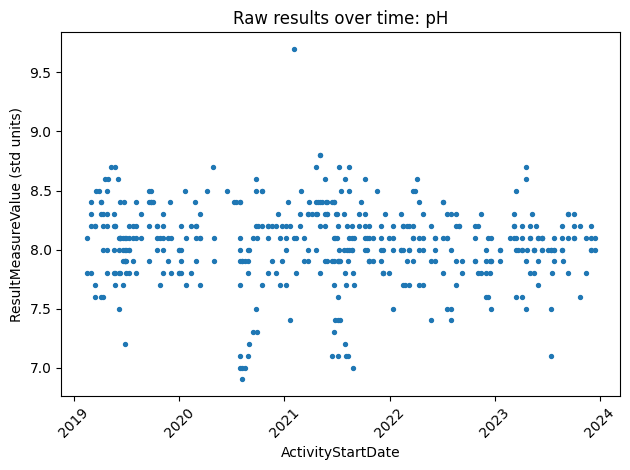

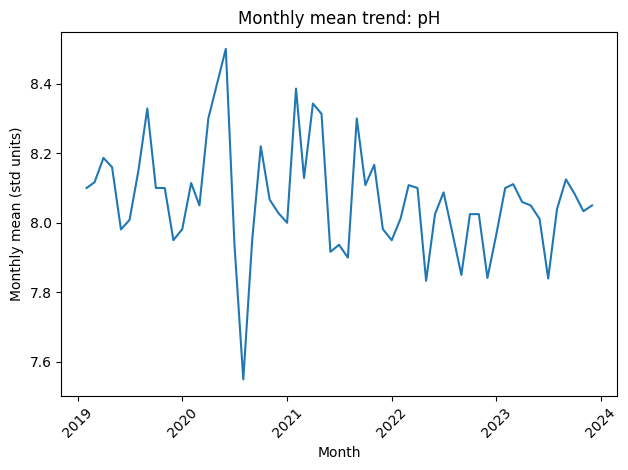

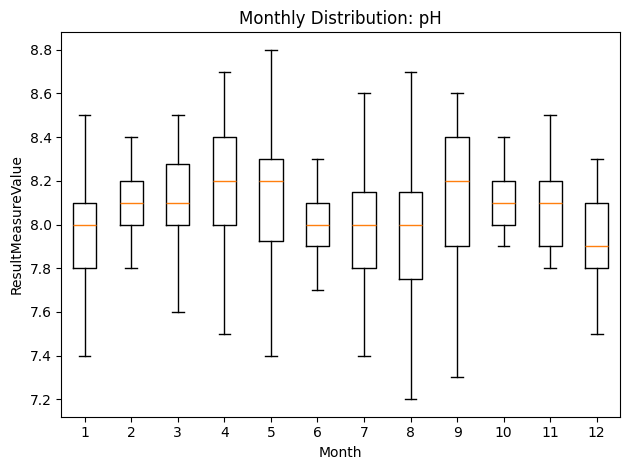

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

data = df_target.copy()

# basic cleaning
data["ActivityStartDate"] = pd.to_datetime(data["ActivityStartDate"], errors="coerce")

# ensure measurements are numeric values
data["ResultMeasureValue"] = pd.to_numeric(data["ResultMeasureValue"], errors="coerce")

# (optional) only keep data labeled as "accepted," note that this removes majority of data
# data = data[data["ResultStatusIdentifier"].astype(str).str.lower().eq("accepted")]

# drop rows missing critical fields
data = data.dropna(subset=["ActivityStartDate", "CharacteristicName", "ResultMeasureValue"])

print("num rows after cleaning:", len(data))
print("unique characteristics:", data["CharacteristicName"].nunique())

# pick a characteristic
# char = data["CharacteristicName"].value_counts().index[2]  # change the index for a common measurement
# or
char = 'pH'  # hardcode

dchar = data[data["CharacteristicName"] == char].copy()

# multiple units exist --> pick the most common unit to avoid unit-mixing in plots
if "ResultMeasure/MeasureUnitCode" in dchar.columns:
    # Check if there are any non-null units for the characteristic
    if dchar["ResultMeasure/MeasureUnitCode"].notna().any():
        unit = dchar["ResultMeasure/MeasureUnitCode"].value_counts().index[0]
        dchar = dchar[dchar["ResultMeasure/MeasureUnitCode"] == unit]
    else:
        unit = None
else:
    unit = None

print("Plotting characteristic:", char, "| unit:", unit)

# plot A: raw time series (all points)
plt.figure()
plt.scatter(dchar["ActivityStartDate"], dchar["ResultMeasureValue"], s=8)
plt.xlabel("ActivityStartDate")
plt.ylabel("ResultMeasureValue" + (f" ({unit})" if unit else ""))
plt.title(f"Raw results over time: {char}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot B: monthly average trend
monthly = (
    dchar.set_index("ActivityStartDate")["ResultMeasureValue"]
         .resample("MS")
         .mean()
         .dropna()
)

plt.figure()
plt.plot(monthly.index, monthly.values)
plt.xlabel("Month")
plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
plt.title(f"Monthly mean trend: {char}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot C: monthly boxplots (distribution by month), can be yearly when we have more data
dchar["Month"] = dchar["ActivityStartDate"].dt.month

months = list(range(1, 13))

box_data = [
    dchar.loc[dchar["Month"] == m, "ResultMeasureValue"].dropna().values
    for m in months
]

plt.figure()
plt.boxplot(box_data, tick_labels=months, showfliers=False)
plt.xlabel("Month")
plt.ylabel("ResultMeasureValue")
plt.title(f"Monthly Distribution: {char}")
plt.tight_layout()
plt.show()


In [32]:
# visualizations for multiple characteristics
def plot_wqp_characteristic_trends(
    df: pd.DataFrame,
    characteristics,
    date_col: str = "ActivityStartDate",
    char_col: str = "CharacteristicName",
    value_col: str = "ResultMeasureValue",
    unit_col: str = "ResultMeasure/MeasureUnitCode",
    only_accepted: bool = False,
    status_col: str = "ResultStatusIdentifier",
    choose_unit: str = "most_common",   # "most_common" or a specific unit string
    showfliers: bool = False,
    point_size: int = 8
):
    """
    For each characteristic in `characteristics`, plots:
      A) raw scatter over time
      B) monthly mean trend
      C) monthly boxplots (distribution by month)

    Notes:
      - Drops rows with missing date/characteristic/value
      - Coerces date/value types
      - Optionally filters to accepted results
      - If multiple units exist, can pick the most common unit to avoid mixing
    """
    # Normalize characteristics input
    if isinstance(characteristics, str):
        characteristics = [characteristics]

    data = df.copy()

    # Basic cleaning
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    if only_accepted and status_col in data.columns:
        data = data[data[status_col].astype(str).str.lower().eq("accepted")]

    # Drop rows missing critical fields
    data = data.dropna(subset=[date_col, char_col, value_col])

    print("num rows after cleaning:", len(data))
    print("unique characteristics:", data[char_col].nunique())

    for char in characteristics:
        dchar = data[data[char_col] == char].copy()

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after filtering).")
            continue

        # Unit handling
        unit = None
        if unit_col in dchar.columns:
            if choose_unit == "most_common":
                unit = dchar[unit_col].dropna().value_counts().index[0] if dchar[unit_col].notna().any() else None
                if unit is not None:
                    dchar = dchar[dchar[unit_col] == unit]
            else:
                unit = choose_unit
                dchar = dchar[dchar[unit_col] == unit]

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after unit filter).")
            continue

        print("Plotting characteristic:", char, "| unit:", unit)

        # ---- Plot A: raw time series (scatter) ----
        plt.figure(figsize=(4, 3))
        plt.scatter(dchar[date_col], dchar[value_col], s=point_size)
        plt.xlabel(date_col)
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Raw results over time: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot B: monthly mean trend ----
        monthly = (
            dchar.set_index(date_col)[value_col]
                .resample("MS")
                .mean()
                .dropna()
        )

        plt.figure(figsize=(4, 3))
        plt.plot(monthly.index, monthly.values)
        plt.xlabel("Month")
        plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly mean trend: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot C: monthly boxplots ----
        dchar["Month"] = dchar[date_col].dt.month
        months = list(range(1, 13))

        box_data = [
            dchar.loc[dchar["Month"] == m, value_col].dropna().values
            for m in months
        ]

        plt.figure(figsize=(4, 3))
        plt.boxplot(box_data, labels=months, showfliers=showfliers)
        plt.xlabel("Month")
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly distribution: {char}")
        plt.tight_layout()
        plt.show()


num rows after cleaning: 12040
unique characteristics: 44
Plotting characteristic: pH | unit: None


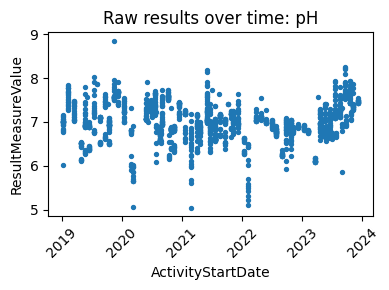

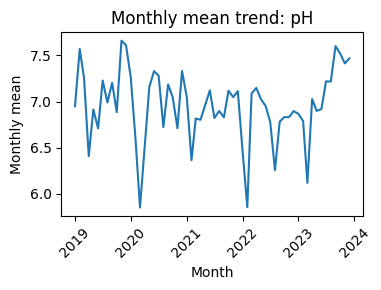

/tmp/ipykernel_423/2269672727.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


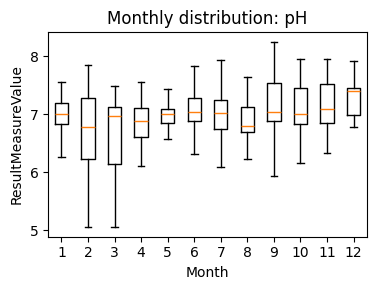

Skipping 'Temperature' (no rows after filtering).
Skipping 'water' (no rows after filtering).
Plotting characteristic: Dissolved oxygen (DO) | unit: mg/L


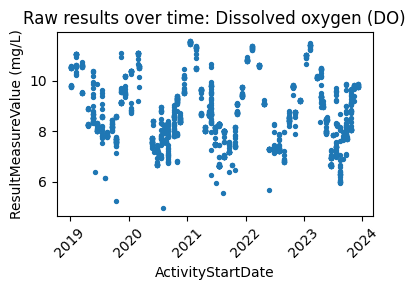

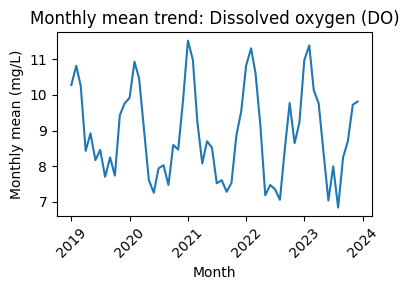

/tmp/ipykernel_423/2269672727.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


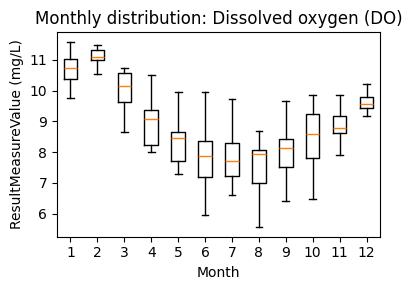

Plotting characteristic: Phosphorus | unit: mg/L


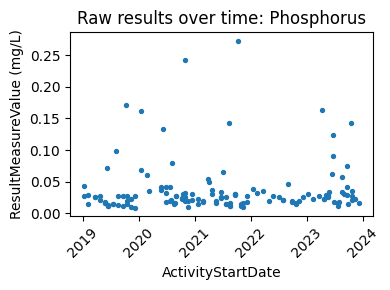

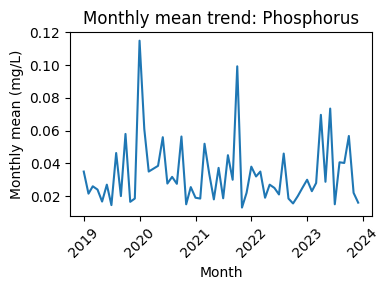

/tmp/ipykernel_423/2269672727.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


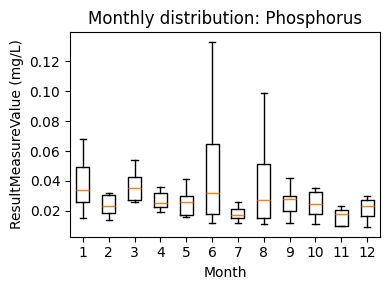

In [33]:
chars = ["pH", "Temperature", "water", "Dissolved oxygen (DO)", "Phosphorus"]
plot_wqp_characteristic_trends(df_target, chars)
